In [2]:
import numpy as np
import cv2
import open3d as o3d

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [31]:
img1 = cv2.imread("/home/aadi_iiith/Desktop/IS/OpenStereo/data/KITTI15/training/image_2/000001_10.png",cv2.IMREAD_UNCHANGED)
img2 = cv2.imread("/home/aadi_iiith/Desktop/IS/OpenStereo/data/KITTI15/training/image_2/000001_11.png",cv2.IMREAD_UNCHANGED)
disp = cv2.imread("depth.png",cv2.IMREAD_GRAYSCALE)
disp2 = cv2.imread("depth2.png",cv2.IMREAD_GRAYSCALE)
disp = cv2.resize(disp,(1242, 375))
disp2 = cv2.resize(disp2,(1242, 375))
disp1 = disp.astype(np.float32)
disp2 = disp2.astype(np.float32)
disp1*=0.75
disp2*=0.75
disp1[:disp2.shape[0]//2,:] = 0
disp1[:disp2.shape[0]//2,:] = 0


In [32]:
depth1 = 4.485728e+01/disp1
depth2 = 4.485728e+01/disp2

/tmp/ipykernel_740741/3750427137.py:1: RuntimeWarning: divide by zero encountered in divide
  depth1 = 4.485728e+01/disp1


In [33]:
import numpy as np


R = np.array([
    [9.998817e-01,  1.511453e-02, -2.841595e-03],
    [-1.511724e-02, 9.998853e-01, -9.338510e-04],
    [2.827154e-03,  9.766976e-04,  9.999955e-01]
])

P = np.array([
    [7.215377e+02, 0.000000e+00, 6.095593e+02, 4.485728e+01],
    [0.000000e+00, 7.215377e+02, 1.728540e+02, 2.163791e-01],
    [0.000000e+00, 0.000000e+00, 1.000000e+00, 2.745884e-03]
])


def recover_K_from_P_and_R(P, R):
    """
    Given P (3x4) and R (3x3), return intrinsic K (3x3).
    Handles the common cases where R is a rotation (uses R.T),
    otherwise uses np.linalg.inv(R).
    Ensures positive diagonal in K and normalizes K[2,2]=1.
    """
    P = np.asarray(P, dtype=float)
    R = np.asarray(R, dtype=float)
    if P.shape != (3, 4):
        raise ValueError("P must be shape (3,4)")
    if R.shape != (3, 3):
        raise ValueError("R must be shape (3,3)")

    M = P[:, :3]  # left 3x3 block

    # Use R.T if R is (almost) orthonormal; otherwise use inverse
    if np.allclose(R @ R.T, np.eye(3), atol=1e-6):
        Rinv = R.T
    else:
        Rinv = np.linalg.inv(R)

    K_raw = M @ Rinv

    # Fix sign on diagonal: enforce positive diagonal entries
    diag_sign = np.sign(np.diag(K_raw))
    # replace zeros with +1 (in case any diag element is exactly 0)
    diag_sign[diag_sign == 0] = 1.0
    S = np.diag(diag_sign)
    K_signed = K_raw @ S
    # Optionally adjust R as well: R_corrected = S @ R   (not returned here)

    # Normalize so that K[2,2] == 1
    K = K_signed / K_signed[2, 2]

    return K

# Example usage:
# P = np.array([...]).reshape(3,4)
# R = np.array([...]).reshape(3,3)
K = recover_K_from_P_and_R(P, R)
print(K)


[[ 7.19723460e+02 -1.14769478e+01  6.11599207e+02]
 [ 1.04145690e+01  7.21296766e+02  1.73558727e+02]
 [-2.84160779e-03 -9.33855202e-04  1.00000000e+00]]


In [34]:
rgbd_1 = o3d.geometry.RGBDImage.create_from_color_and_depth(
    o3d.geometry.Image(img1),
    o3d.geometry.Image(depth1.astype(np.float32)),
    depth_scale=1e-3, depth_trunc=3000.0, convert_rgb_to_intensity=False)
intrinsic = o3d.camera.PinholeCameraIntrinsic()
intrinsic.intrinsic_matrix = K
pcd_1 = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd_1, intrinsic)


rgbd_2 = o3d.geometry.RGBDImage.create_from_color_and_depth(
    o3d.geometry.Image(img2),
    o3d.geometry.Image(depth2.astype(np.float32)),
    depth_scale=1e-3, depth_trunc=3000.0, convert_rgb_to_intensity=False)
intrinsic = o3d.camera.PinholeCameraIntrinsic()
intrinsic.intrinsic_matrix = K
pcd_2 = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd_2, intrinsic)


In [36]:
o3d.visualization.draw_geometries([pcd_2])

In [38]:
init_trans = np.eye(4)

# Run ICP
threshold = 5  # distance threshold
reg_icp = o3d.pipelines.registration.registration_icp(
    pcd_1, pcd_2, threshold, init_trans,
    o3d.pipelines.registration.TransformationEstimationPointToPoint()
)

print("ICP transformation:\n", reg_icp.transformation)

# Transform source
pcd_1_icp = pcd_1.transform(reg_icp.transformation)

# Visualize before and after
print("Showing alignment before ICP...")
o3d.visualization.draw_geometries([pcd_1.paint_uniform_color([1, 0, 0]),
                                   pcd_2.paint_uniform_color([0, 1, 0])])

print("Showing alignment after ICP...")
o3d.visualization.draw_geometries([pcd_1_icp.paint_uniform_color([1, 0, 0]),
                                   pcd_2.paint_uniform_color([0, 1, 0])])

ICP transformation:
 [[ 9.99998156e-01 -1.91949386e-03  6.41494425e-05  2.93041707e-01]
 [ 1.91936214e-03  9.99996170e-01  1.99396776e-03  3.76960563e-01]
 [-6.79766056e-05 -1.99384096e-03  9.99998010e-01  3.86344498e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Showing alignment before ICP...
Showing alignment after ICP...


000000_10.png: last zero row before nonzero = 124
000001_10.png: last zero row before nonzero = 98
000002_10.png: last zero row before nonzero = 120
000003_10.png: last zero row before nonzero = 99
000004_10.png: last zero row before nonzero = 121
000005_10.png: last zero row before nonzero = 118
000006_10.png: last zero row before nonzero = 117
000007_10.png: last zero row before nonzero = 122
000008_10.png: last zero row before nonzero = 116
000009_10.png: last zero row before nonzero = 109
000010_10.png: last zero row before nonzero = 124
000011_10.png: last zero row before nonzero = 121
000012_10.png: last zero row before nonzero = 119
000013_10.png: last zero row before nonzero = 116
000014_10.png: last zero row before nonzero = 116
000015_10.png: last zero row before nonzero = 130
000016_10.png: last zero row before nonzero = 129
000017_10.png: last zero row before nonzero = 129
000018_10.png: last zero row before nonzero = 123
000019_10.png: last zero row before nonzero = 114
00

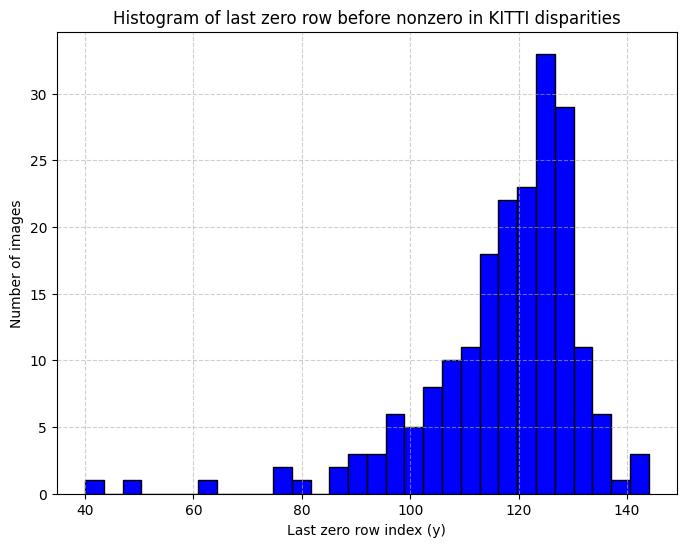

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def find_last_zero_before_nonzero(img):
    """
    Scan from top to bottom, return the last row index that is all zeros
    before the first non-zero row appears.
    If the image starts with non-zero pixels, return -1.
    """
    last_zero_row = -1
    for y in range(img.shape[0]):
        if np.all(img[y, :] == 0):
            last_zero_row = y
        else:
            break  # stop as soon as we hit first non-zero row
    return last_zero_row

def process_folder(folder_path):
    results = {}
    for fname in sorted(os.listdir(folder_path)):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            fpath = os.path.join(folder_path, fname)
            img = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            y = find_last_zero_before_nonzero(img)
            results[fname] = y
    return results

# Example usage
folder = "/home/aadi_iiith/Desktop/IS/OpenStereo/data/KITTI15/training/disp_noc_0/"
results = process_folder(folder)

# Collect all values
values = list(results.values())

# Print results
for fname, y in results.items():
    print(f"{fname}: last zero row before nonzero = {y}")

# Plot histogram
plt.figure(figsize=(8,6))
plt.hist(values, bins=30, color="blue", edgecolor="black")
plt.xlabel("Last zero row index (y)")
plt.ylabel("Number of images")
plt.title("Histogram of last zero row before nonzero in KITTI disparities")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()
